In [1]:
!mkdir -p /content/dataset # first we connected to where we stored our classification data locally
!cp -r /content/drive/Shareddrives/CaseathonFall2025/ImageClassification/classification_dataset/* /content/dataset/

In [2]:
# Imports
import os
import csv
import json
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# =====================
# 1. Custom Dataset to work with our data and loading
# =====================
class CustomDataset(Dataset):
    def __init__(self, img_dir, label_file, transform=None, cache=False):
        self.img_dir = img_dir
        self.transform = transform
        self.cache = cache
        self.images, self.labels = [], []
        self.label_to_idx = {}
        self.cache_data = {}

        # Read labels
        with open(label_file, "r") as f:
            for line in f:
                img_name, label = line.strip().split()
                self.images.append(img_name)
                self.labels.append(label)

        # Encode string labels into integers
        unique_labels = sorted(set(self.labels))
        self.label_to_idx = {label: i for i, label in enumerate(unique_labels)}
        self.labels = [self.label_to_idx[l] for l in self.labels]

        # Optional caching
        if cache:
            print("⚡ Caching images into memory...")
            for img_name in tqdm(self.images):
                path = os.path.join(self.img_dir, img_name)
                self.cache_data[img_name] = Image.open(path).convert("RGB")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        label = self.labels[idx]
        if self.cache and img_name in self.cache_data:
            image = self.cache_data[img_name]
        else:
            path = os.path.join(self.img_dir, img_name)
            image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


# =====================
# 2. Transformations to reduce computation requirements
# =====================
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# =====================
# 3. Dataset Setup
# =====================
img_dir = "/content/dataset/images"
label_file = "/content/dataset/labels.txt"
dataset = CustomDataset(img_dir, label_file, transform=transform, cache=False)

train_idx, val_idx = train_test_split(range(len(dataset)), test_size=0.2, random_state=42)
train_dataset = torch.utils.data.Subset(dataset, train_idx)
val_dataset = torch.utils.data.Subset(dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=8, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=8, pin_memory=True)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Using device: cuda


In [5]:
# =====================
# 4. Model Setup
# =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(set(dataset.labels))

model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# =====================
# 5. Logging Setup
# =====================
results_dir = "/content/drive/Shareddrives/CaseathonFall2025/ImageClassification/results/resnet50_640px"
os.makedirs(results_dir, exist_ok=True)

# Save config
config = {
    "model": "resnet50",
    "epochs": 10,
    "batch_size": 64,
    "learning_rate": 1e-4,
    "train_size": len(train_dataset),
    "val_size": len(val_dataset),
    "num_classes": num_classes
}
with open(os.path.join(results_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=4)

# CSV header
metrics_path = os.path.join(results_dir, "metrics.csv")
with open(metrics_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "train_loss", "train_acc", "val_acc"])

# =====================
# 6. Training Loop
# =====================
epochs = config["epochs"]

for epoch in range(epochs):
    model.train()
    train_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    train_acc = 100. * correct / total
    avg_loss = train_loss / total

    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100. * val_correct / val_total

    # Log results
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    with open(metrics_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([epoch + 1, avg_loss, train_acc, val_acc])

    # Save checkpoint (weights + optimizer + metrics)
    checkpoint_path = os.path.join(results_dir, f"checkpoint_epoch{epoch+1}.pth")
    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": avg_loss,
        "train_acc": train_acc,
        "val_acc": val_acc
    }, checkpoint_path)

# =====================
# 7. Save Final Model
# =====================
final_model_path = os.path.join(results_dir, f"resnet50_final.pth")
torch.save(model.state_dict(), final_model_path)
print(f"\n✅ Training complete! Final model and logs saved in: {results_dir}")

Epoch 1/10: 100%|██████████| 132/132 [01:41<00:00,  1.30it/s]


Epoch [1/10] | Loss: 0.7902 | Train Acc: 73.14% | Val Acc: 86.86%


Epoch 2/10: 100%|██████████| 132/132 [01:41<00:00,  1.30it/s]


Epoch [2/10] | Loss: 0.2369 | Train Acc: 93.06% | Val Acc: 88.95%


Epoch 3/10: 100%|██████████| 132/132 [01:41<00:00,  1.31it/s]


...

Epoch [8/10] | Loss: 0.0789 | Train Acc: 97.50% | Val Acc: 90.10%


Epoch 9/10: 100%|██████████| 132/132 [01:43<00:00,  1.27it/s]


Epoch [9/10] | Loss: 0.0234 | Train Acc: 99.40% | Val Acc: 89.90%


Epoch 10/10: 100%|██████████| 132/132 [01:42<00:00,  1.29it/s]


Epoch [10/10] | Loss: 0.0187 | Train Acc: 99.58% | Val Acc: 90.33%

✅ Training complete! Final model and logs saved in: /content/drive/Shareddrives/CaseathonFall2025/ImageClassification/results/resnet50_640px


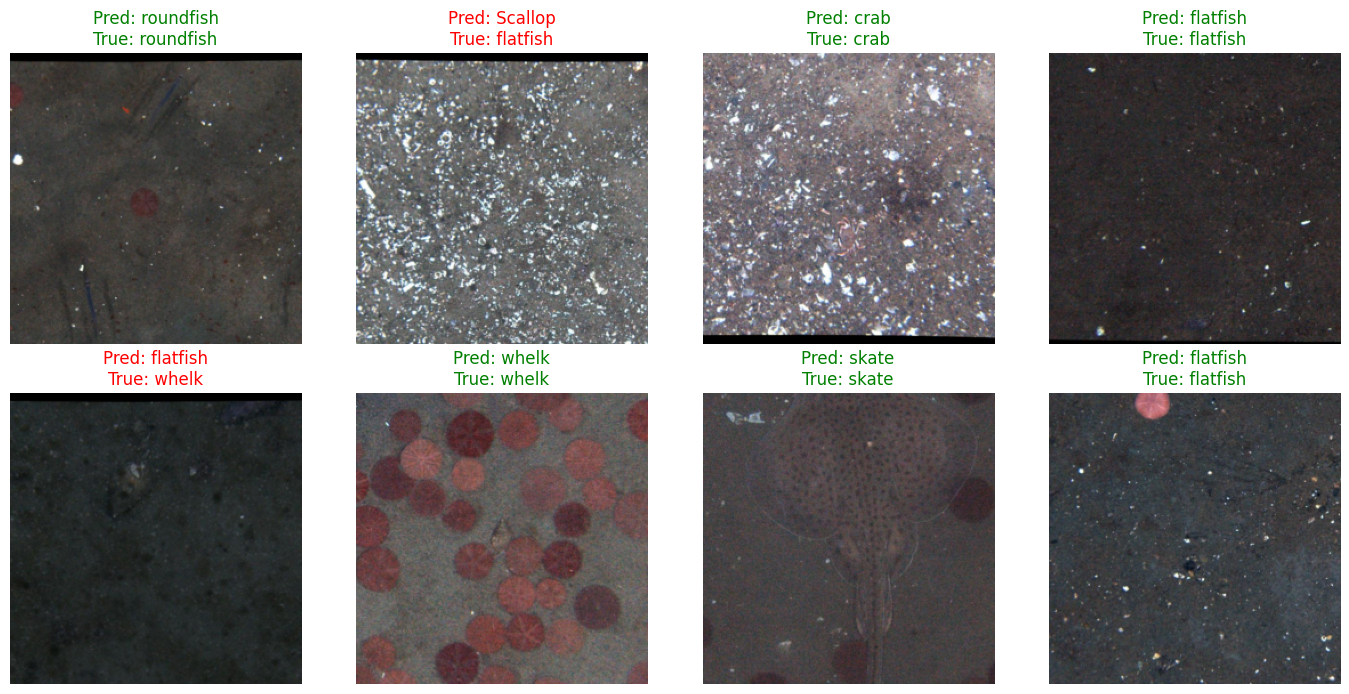

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid
results_dir = "/content/drive/Shareddrives/CaseathonFall2025/ImageClassification/results/resnet50_experiment"
# =====================
# 1. Load Trained Model
# =====================
checkpoint_path = os.path.join(results_dir, "resnet50_final.pth")
model.load_state_dict(torch.load(checkpoint_path, map_location=device)) # tried to run this cell by itself, didn't work  because model here is not defined
model.eval()

# Reverse label mapping for display
idx_to_label = {v: k for k, v in dataset.label_to_idx.items()}

# =====================
# 2. Get a Few Samples
# =====================
sample_loader = DataLoader(val_dataset, batch_size=8, shuffle=True)
images, labels = next(iter(sample_loader))
images, labels = images.to(device), labels.to(device)

# =====================
# 3. Run Predictions
# =====================
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

# =====================
# 4. Visualization Function
# =====================
def show_predictions(images, labels, preds, idx_to_label):
    images = images.cpu()
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i >= len(images):
            ax.axis("off")
            continue
        img = images[i].permute(1, 2, 0).numpy()
        img = np.clip(img * np.array([0.229, 0.224, 0.225]) +
                      np.array([0.485, 0.456, 0.406]), 0, 1)
        ax.imshow(img)
        true_label = idx_to_label[labels[i].item()]
        pred_label = idx_to_label[preds[i].item()]
        color = "green" if true_label == pred_label else "red"
        ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# =====================
# 5. Display Results
# =====================
show_predictions(images, labels, preds, idx_to_label)
